# Logistic Regression — Single Feature
**Dataset:** Heart Disease Prediction  
**Feature:** Cholesterol  
**Target:** Heart Disease (Presence / Absence)

## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

## 2. Data Retrieval and Collection

In [2]:
# Load the Heart Disease dataset

# Alternative simpler approach (commented out):
# def load_dataset(filepath):
#     df = pd.read_csv(filepath)
#     return df

def load_dataset(filepath):
    # Using a context manager ensures the file is closed properly after reading
    with open(filepath, 'r') as f:
        df = pd.read_csv(f)
        return df

df = load_dataset('Heart_Disease_Prediction.csv')

## 3. Data Exploration

In [3]:
# Display dataset shape and column names
def display_info(df):
    print('Dataset Shape:', df.shape)
    print('Column Names:', df.columns.tolist())
    print(df.head(5))

display_info(df)

Dataset Shape: (270, 14)
Column Names: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']
   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0            2.4            2   
1     160                0            1.6            2   
2     141                0            0.3            1   
3     105                1            0.2            2   
4    

In [4]:
# Brief statistical summary of the dataset
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


## 4. Data Cleaning and Preprocessing

In [5]:
# Check for missing and duplicate values
def check_missing(df):
    null_val = df.isnull().sum()   # count null values per column
    dup_val  = df.duplicated().sum()  # count duplicate rows
    return null_val, dup_val

check_missing(load_dataset('Heart_Disease_Prediction.csv'))

(Age                        0
 Sex                        0
 Chest pain type            0
 BP                         0
 Cholesterol                0
 FBS over 120               0
 EKG results                0
 Max HR                     0
 Exercise angina            0
 ST depression              0
 Slope of ST                0
 Number of vessels fluro    0
 Thallium                   0
 Heart Disease              0
 dtype: int64,
 np.int64(0))

In [6]:
# Ensure the target variable is binary (exactly 2 unique values)
df['Heart Disease'].nunique() == 2

True

In [7]:
# Verify and cast column data types as needed
df.dtypes

if df.dtypes['Heart Disease'] != 'str':
    df['Heart Disease'] = df['Heart Disease'].astype(str)

if df.dtypes['Age'] != 'int64':
    df['Age'] = df['Age'].astype(int)

# Repeat for remaining columns as needed

## 5. Feature Design and Selection

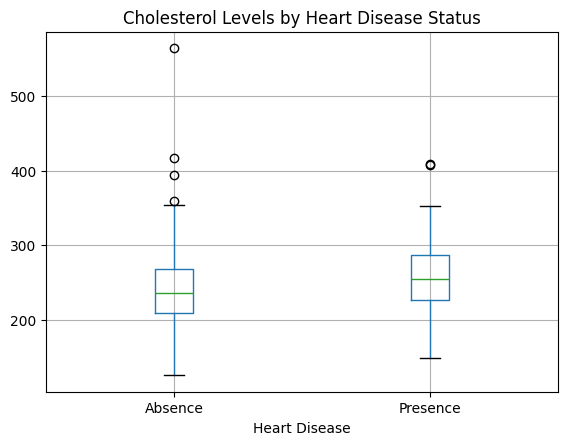

In [8]:
# Select feature (X) and target (Y)
# Double brackets [[ ]] keep X as a 2D DataFrame — required by sklearn
X = df[['Cholesterol']]   # single feature: Cholesterol
Y = df['Heart Disease']

# Visualise the relationship between Cholesterol and Heart Disease
# A box plot is more appropriate here because the target is binary
df.boxplot(column='Cholesterol', by='Heart Disease')
plt.title('Cholesterol Levels by Heart Disease Status')
plt.suptitle('')   # remove the default auto-generated suptitle
plt.show()

# Observation: patients with higher cholesterol tend to have heart disease,
# suggesting Cholesterol is a reasonable predictor.
# We will quantify this relationship with logistic regression.

## 6. Algorithm — Logistic Regression
Logistic regression is suitable here because the target variable (Heart Disease) is **binary** (Presence / Absence). It models the probability of the outcome using a logistic (sigmoid) function applied to the linear combination of features.

In [9]:
# Split data into training (80 %) and testing (20 %) sets
# random_state=42 ensures reproducibility across runs
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print('Training set shape:', X_train.shape, Y_train.shape)
print('Testing set shape: ', X_test.shape,  Y_test.shape)
print(X_test.head(5))
print(Y_test.head(5))

Training set shape: (216, 1) (216,)
Testing set shape:  (54, 1) (54,)
     Cholesterol
30           229
116          249
79           236
127          196
196          248
30     Presence
116    Presence
79      Absence
127     Absence
196     Absence
Name: Heart Disease, dtype: str


In [10]:
# Confirm shapes — X should be (n_samples, 1) because we used double brackets
# No manual reshaping is needed since df[['Cholesterol']] is already 2-D
#
#   X_train = X_train.values.reshape(-1, 1)  ← not required
#   X_test  = X_test.values.reshape(-1, 1)   ← not required

print('X_train shape:', X_train.shape)   # expected (216, 1)
print('X_test  shape:', X_test.shape)    # expected  (54, 1)
print('Y shapes      :', Y_train.shape, Y_test.shape)

# Y is already 1-D (n_samples,) — correct format for sklearn

X_train shape: (216, 1)
X_test  shape: (54, 1)
Y shapes      : (216,) (54,)


In [11]:
# Train the logistic regression model
logistic_model = LogisticRegression()
logistic_model.fit(X_train, Y_train)

# The model learns the relationship between Cholesterol levels
# and Heart Disease presence, enabling predictions on new data.

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 7. Model Evaluation

In [12]:
# Compute classification metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, log_loss
)

Y_pred = logistic_model.predict(X_test)

accuracy  = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred, pos_label='Presence')
recall    = recall_score(Y_test,    Y_pred, pos_label='Presence')
f1        = f1_score(Y_test,        Y_pred, pos_label='Presence')

print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1 Score : {f1:.4f}')

# Confusion matrix (rows = actual, cols = predicted)
conf_matrix = confusion_matrix(Y_test, Y_pred, labels=['Presence', 'Absence'])
print('\nConfusion Matrix:\n', conf_matrix)

Accuracy : 0.6111
Precision: 0.5000
Recall   : 0.2381
F1 Score : 0.3226

Confusion Matrix:
 [[ 5 16]
 [ 5 28]]


## 8. Loss Function — Binary Cross-Entropy (Log Loss)
Binary Cross-Entropy is the standard loss for binary classification. It measures how well the predicted probabilities match the true labels.

In [13]:
# Predict class probabilities and compute log loss
Y_prob = logistic_model.predict_proba(X_test)  # shape: (n_samples, 2)
loss   = log_loss(Y_test, Y_prob, labels=['Absence', 'Presence'])

print(f'Log Loss: {loss:.6f}')

Log Loss: 0.660867
